In [ ]:
!pip install catboost category_encoders optuna shap umap-learn xgboost lightgbm imbalanced-learn

#  Best Model Submission in a Titanic Survival Prediction Competition

<>:34: SyntaxWarning: invalid escape sequence '\.'
<>:34: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-443843016.py:34: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Fold 1 | Train Acc: 0.9003 | Val Acc: 0.8715
Fold 2 | Train Acc: 0.9046 | Val Acc: 0.8652
Fold 3 | Train Acc: 0.9102 | Val Acc: 0.8315
Fold 4 | Train Acc: 0.9060 | Val Acc: 0.8427
Fold 5 | Train Acc: 0.9060 | Val Acc: 0.8371

===== OVERALL METRICS =====
Mean Train Accuracy: 0.9054418740249304
Mean Val Accuracy: 0.8495825748540582
Train-Val Gap: 0.05585929917087218
OOF Accuracy: 0.8496071829405163


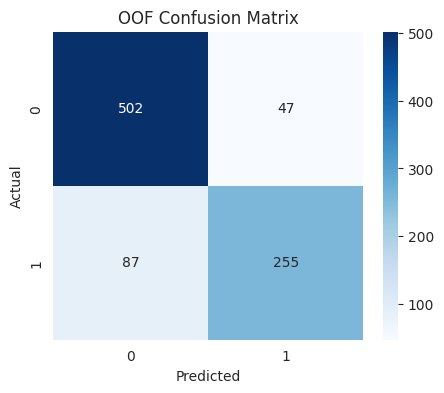

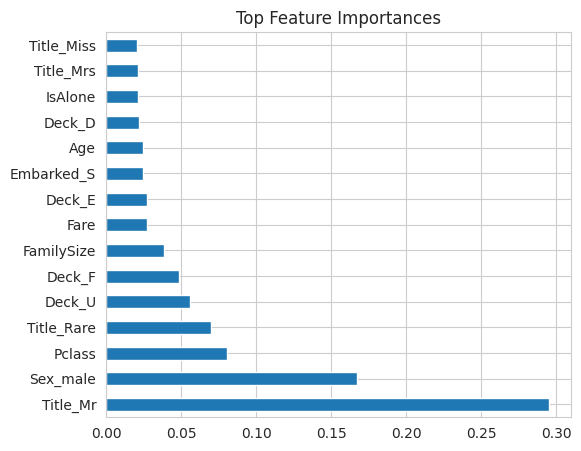

submission.csv saved


In [25]:


# ✅ TITANIC — MODEL DIAGNOSTICS & OVERFITTING CHECK (SHAREABLE)


# ==========================================
# TITANIC MODEL DIAGNOSTICS SCRIPT
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

sns.set_style("whitegrid")

# ==========================================
# STEP 1: LOAD DATA
# ==========================================
train = pd.read_csv('/content/train.csv')
test  = pd.read_csv('/content/test.csv')

# ==========================================
# STEP 2: FEATURE ENGINEERING
# ==========================================
def feature_engineering(df):
    df = df.copy()

    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
        'Rare'
    )
    df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    df['Deck'] = df['Cabin'].str[0].fillna('U')
    df['Embarked'] = df['Embarked'].fillna('S')
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

    return df

train = feature_engineering(train)
test  = feature_engineering(test)

# ==========================================
# STEP 3: AGE IMPUTATION
# ==========================================
for df in [train, test]:
    df['Age'] = df.groupby(['Title','Pclass','Sex'])['Age']\
                   .transform(lambda x: x.fillna(x.median()))

# ==========================================
# STEP 4: FEATURE SELECTION
# ==========================================
features = [
    'Pclass','Sex','Age','Fare','Embarked',
    'Title','FamilySize','IsAlone','Deck'
]

X = pd.get_dummies(train[features], drop_first=True)
y = train['Survived']

# ==========================================
# STEP 5: MODELS
# ==========================================
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42
)

ensemble = VotingClassifier(
    estimators=[('xgb', xgb), ('rf', rf)],
    voting='soft'
)

# ==========================================
# STEP 6: CROSS-VALIDATION DIAGNOSTICS
# ==========================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_scores = []
val_scores = []
oof_preds = np.zeros(len(X))

for fold, (tr, val) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr], X.iloc[val]
    y_tr, y_val = y.iloc[tr], y.iloc[val]

    ensemble.fit(X_tr, y_tr)

    train_pred = ensemble.predict(X_tr)
    val_pred   = ensemble.predict(X_val)

    tr_acc = accuracy_score(y_tr, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    train_scores.append(tr_acc)
    val_scores.append(val_acc)

    oof_preds[val] = val_pred

    print(f"Fold {fold} | Train Acc: {tr_acc:.4f} | Val Acc: {val_acc:.4f}")

# ==========================================
# STEP 7: SUMMARY METRICS
# ==========================================
print("\n===== OVERALL METRICS =====")
print("Mean Train Accuracy:", np.mean(train_scores))
print("Mean Val Accuracy:", np.mean(val_scores))
print("Train-Val Gap:", np.mean(train_scores) - np.mean(val_scores))
print("OOF Accuracy:", accuracy_score(y, oof_preds))

# ==========================================
# STEP 8: CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y, oof_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("OOF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================
# STEP 9: FEATURE IMPORTANCE (XGBoost)
# ==========================================
xgb.fit(X, y)
importances = pd.Series(xgb.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(
    kind='barh', figsize=(6,5), title="Top Feature Importances"
)
plt.show()

# ==========================================
# STEP 10: FINAL TRAIN & SUBMISSION
# ==========================================
ensemble.fit(X, y)
test_X = pd.get_dummies(test[features], drop_first=True)
test_X = test_X.reindex(columns=X.columns, fill_value=0)

test_pred = ensemble.predict(test_X)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_pred.astype(int)
})

submission.to_csv("submission.csv", index=False)
print("submission.csv saved")


In [26]:
print(classification_report(y, oof_preds))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       549
           1       0.84      0.75      0.79       342

    accuracy                           0.85       891
   macro avg       0.85      0.83      0.84       891
weighted avg       0.85      0.85      0.85       891



Submission and Description

Public Score

submission.csv
Complete · 3m ago
0.77751